In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import sys
import re
from tqdm import tqdm

# import some tools from the wider directory
sys.path.insert(0, os.path.abspath('..'))   # adds fastersimulation/ to the path
import utilities
path = "../results/controller_sweep/"
out_path = os.path.join(path, "combined_sweep.h5")
collate=True

In [2]:
if collate:
    def _parse_folder(folder_name):
        """
        Extract calkp, calkd, obskp, obskd, obski from folder names like:
        calkp1.0_calkd20.0_obskp25.0_obskd100.0_obski0.10
        """
        m = re.search(
            r"^calkp([^_]+)_calkd([^_]+)_obskp([^_]+)_obskd([^_]+)_obski([^_]+)$",
            folder_name
        )
        if m:
            try:
                return (
                    float(m.group(1)),  # calkp
                    float(m.group(2)),  # calkd
                    float(m.group(3)),  # obskp
                    float(m.group(4)),  # obskd
                    float(m.group(5)),  # ki
                )
            except ValueError:
                pass
        return -1.0, -1.0, -1.0, -1.0, -1.0

    # Discover all simulation folders
    sweep_dirs = [
        d for d in os.listdir(path)
        if os.path.isdir(os.path.join(path, d)) and d.startswith("calkp")
    ]

    # Sort hierarchically by calkp, calkd, obskp, obskd, ki
    sweep_dirs.sort(key=lambda d: _parse_folder(d))

    out_path = os.path.join(path, "combined_sweep.h5")
    missing = []

    print(f"Collating {len(sweep_dirs)} folders into {out_path}...")

    with h5py.File(out_path, "w") as out_f:
        for folder in tqdm(sweep_dirs):
            calkp, calkd, obskp, obskd, ki = _parse_folder(folder)

            if calkp < 0:
                print(f"  [SKIP] {folder} — could not parse parameters")
                continue

            h5_path = os.path.join(path, folder, "mirror_states.h5")
            if not os.path.isfile(h5_path):
                print(f"  [SKIP] calkp={calkp}, calkd={calkd}, obskp={obskp}, obskd={obskd}, ki={ki} — mirror_states.h5 not found")
                missing.append(folder)
                continue

            group_name = f"calkp_{calkp:.6g}_calkd_{calkd:.6g}_obskp_{obskp:.6g}_obskd_{obskd:.6g}_ki_{ki:.6g}"

            with h5py.File(h5_path, "r") as src_f:
                dst_grp = out_f.create_group(group_name)
                for key in src_f.keys():
                    src_f.copy(key, dst_grp, name=key)

    print(f"\nSaved combined file → {out_path}")
    if missing:
        print(f"WARNING: {len(missing)} folders had no mirror_states.h5 file!")


Collating 8 folders into ../results/controller_sweep/combined_sweep.h5...


100%|██████████| 8/8 [00:01<00:00,  4.65it/s]



Saved combined file → ../results/controller_sweep/combined_sweep.h5


In [3]:
def _h5_tree(item, indent=0, max_seg=2, first_only=False):
    """Recursively print an HDF5 tree, optionally only the first root group."""
    prefix = "  " * indent

    def _parse_root_group(name):
        if not name.startswith("a_"):
            return (-1.0, -1.0, -1.0, -1.0)
        parts = name.split("_")
        try:
            return (
                float(parts[1]),
                float(parts[3]),
                float(parts[5]),
                float(parts[7]),
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0, -1.0, -1.0)

    def _segment_index(name):
        try:
            return int(name.split("_")[1])
        except (IndexError, ValueError):
            return -1

    if isinstance(item, h5py.File):
        print(f"{prefix}/ (attrs: {dict(item.attrs)})")

        children = sorted(item.keys(), key=_parse_root_group)

        if first_only and children:
            _h5_tree(item[children[0]], indent + 1, max_seg, first_only)
        else:
            for k in children:
                _h5_tree(item[k], indent + 1, max_seg, first_only)

    elif isinstance(item, h5py.Group):
        name = item.name.split("/")[-1]
        children = list(item.keys())

        seg_keys = sorted(
            [k for k in children if k.startswith("segment_")],
            key=_segment_index
        )
        other_keys = sorted(
            [k for k in children if not k.startswith("segment_")]
        )

        print(f"{prefix}┣ {name}/")

        for k in other_keys:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        for k in seg_keys[:max_seg]:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        if len(seg_keys) > max_seg:
            print(f"{'  ' * (indent + 1)}┆ ... ({len(seg_keys) - max_seg} more segment_ groups)")

    elif isinstance(item, h5py.Dataset):
        name = item.name.split("/")[-1]
        print(f"{prefix}┃  {name:30s}  {str(item.shape):20s}  {item.dtype}")


# ── Execute ──
with h5py.File(out_path, "r") as f:
    _h5_tree(f, max_seg=1, first_only=True)

/ (attrs: {})
  ┣ calkp_1_calkd_20_obskp_25_obskd_100_ki_0.1/
    ┣ config/
      ┃  star_vector                     (3,)                  float64
    ┃  dv                              (256960,)             float64
    ┃  dv_xyz                          (256960, 3)           float64
    ┃  mirror_time                     (9000,)               float64
    ┃  phase                           (256960,)             object
    ┃  r_app_eci                       (256960, 3)           float64
    ┃  r_det_eci                       (256960, 3)           float64
    ┃  rel_pos_B                       (9000, 3)             float64
    ┃  rel_sigma_B                     (256960, 3)           float64
    ┃  sigma_app_star                  (256960, 3)           float64
    ┃  sigma_det_star                  (256960, 3)           float64
    ┃  time                            (256960,)             float64
    ┣ segment_0/
      ┃  desired_mirror_actuation        (9000, 6)             float64
      ┃

In [4]:
import h5py
import numpy as np
from tqdm import tqdm

with h5py.File(out_path, "r") as src_f:

    def _parse_grp(x):
        """
        Parse group names like:
        calkp_1_calkd_20_obskp_25_obskd_100_ki_0.1
        """
        if not x.startswith("calkp_"):
            return (-1.0, -1.0, -1.0, -1.0, -1.0)

        parts = x.split("_")
        try:
            return (
                float(parts[1]),   # calkp
                float(parts[3]),   # calkd
                float(parts[5]),   # obskp
                float(parts[7]),   # obskd
                float(parts[9]),   # ki
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0, -1.0, -1.0, -1.0)

    def _get_ds(run_grp, name):
        if "config" in run_grp and name in run_grp["config"]:
            return run_grp["config"][name][:]
        if name in run_grp:
            return run_grp[name][:]
        raise KeyError(f"Dataset '{name}' not found in '{run_grp.name}' or its config/ group")

    group_keys = sorted(
        [k for k in src_f.keys() if k.startswith("calkp_")],
        key=_parse_grp
    )

    num_runs = len(group_keys)
    print(f"Total number of simulation runs = {num_runs}")

    if num_runs == 0:
        raise ValueError("No simulation groups found in the HDF5 file.")

    phase = []
    full_times = []
    eng_times = []

    calkp_vals = []
    calkd_vals = []
    obskp_vals = []
    obskd_vals = []
    ki_vals    = []

    r_app_eci = []
    r_det_eci = []
    rel_pos_B = []
    dv     = []
    dv_xyz = []

    for group in tqdm(group_keys):
        run_grp = src_f[group]
        calkp, calkd, obskp, obskd, ki = _parse_grp(group)

        calkp_vals.append(calkp)
        calkd_vals.append(calkd)
        obskp_vals.append(obskp)
        obskd_vals.append(obskd)
        ki_vals.append(ki)

        phase_arr = _get_ds(run_grp, "phase")
        phase.append(np.array(phase_arr, dtype=str))

        full_times.append(_get_ds(run_grp, "time"))
        eng_times.append(_get_ds(run_grp, "mirror_time"))

        r_app_eci.append(_get_ds(run_grp, "r_app_eci"))
        r_det_eci.append(_get_ds(run_grp, "r_det_eci"))
        rel_pos_B.append(_get_ds(run_grp, "rel_pos_B"))

        if "config" in run_grp and "dv" in run_grp["config"]:
            dv.append(run_grp["config"]["dv"][:])
        elif "dv" in run_grp:
            dv.append(run_grp["dv"][:])

        if "config" in run_grp and "dv_xyz" in run_grp["config"]:
            dv_xyz.append(run_grp["config"]["dv_xyz"][:])
        elif "dv_xyz" in run_grp:
            dv_xyz.append(run_grp["dv_xyz"][:])

print("Data successfully loaded into lists!")


Total number of simulation runs = 8


100%|██████████| 8/8 [00:02<00:00,  3.37it/s]

Data successfully loaded into lists!


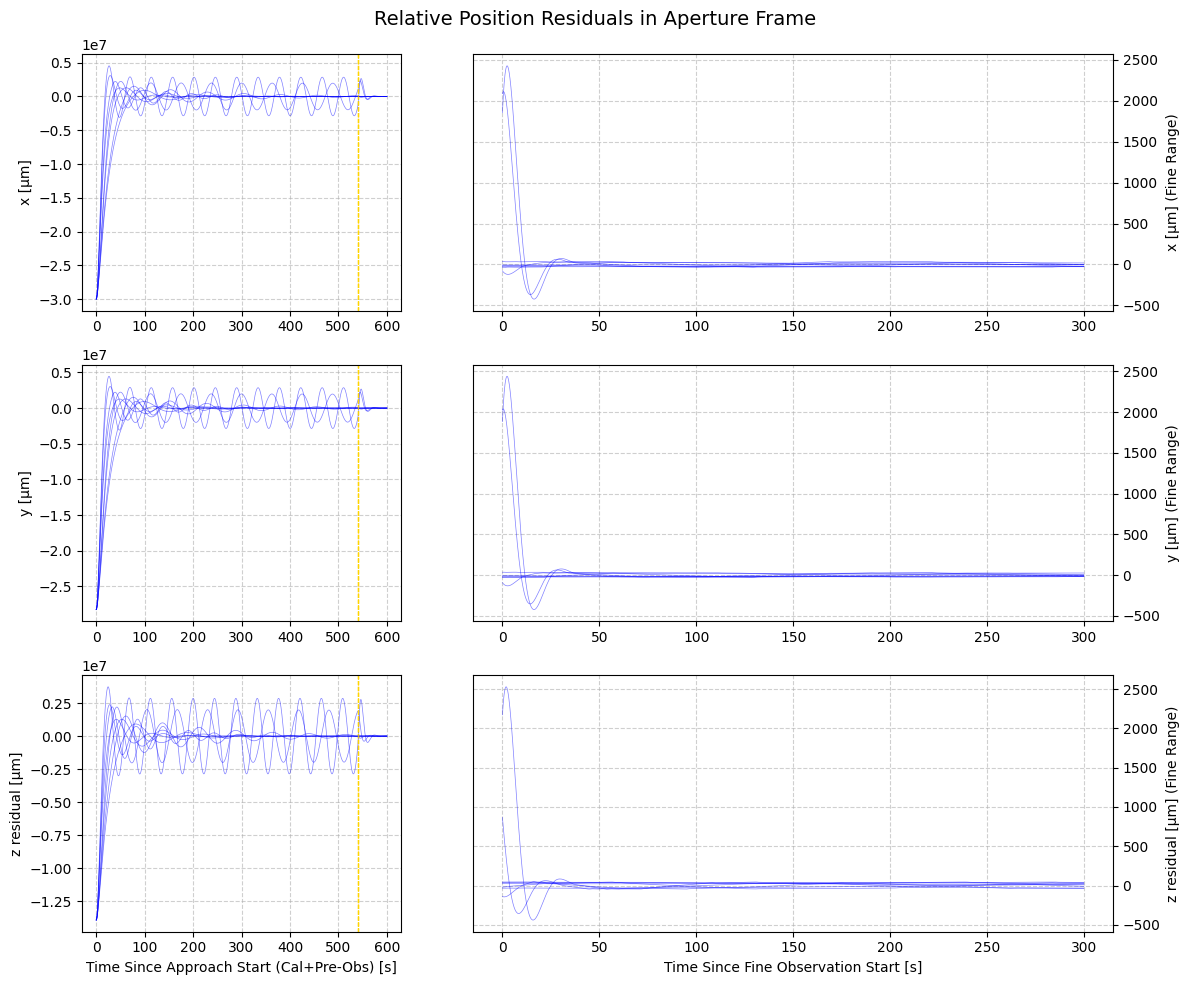

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

coord_letter = ["x", "y", "z"]

alpha_lines   = 0.5
current_focal = 5000.0

rel_pos_fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=rel_pos_fig)
rel_pos_fig.suptitle("Relative Position Residuals in Aperture Frame", fontsize=14)

rel_pos_ax = []
for row in range(3):
    ax_approach = rel_pos_fig.add_subplot(gs[row, 0])
    ax_fine     = rel_pos_fig.add_subplot(gs[row, 1])
    ax_fine.yaxis.tick_right()
    ax_fine.yaxis.set_label_position("right")
    rel_pos_ax.append((ax_approach, ax_fine))

rel_pos_ax[2][0].set_xlabel("Time Since Approach Start (Cal+Pre-Obs) [s]")
rel_pos_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")

for coord in range(3):
    label = coord_letter[coord]
    if coord == 2:
        label = "z residual"
    rel_pos_ax[coord][0].set_ylabel(f"{label} [µm]")
    rel_pos_ax[coord][1].set_ylabel(f"{label} [µm] (Fine Range)")
    rel_pos_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
    rel_pos_ax[coord][1].grid(True, linestyle="--", alpha=0.6)

for i in range(len(phase)):
    t_full  = full_times[i]       # full-rate time — same length as phase array
    t_eng   = eng_times[i]        # mirror-rate time — same length as rel_pos_B
    rel     = rel_pos_B[i]
    phase_i = np.array(phase[i], dtype=str)

    cal_idx     = np.where(phase_i == "Calibration")[0]
    pre_obs_idx = np.where(phase_i == "Pre-Observation")[0]
    fine_idx    = np.where(phase_i == "Fine Observation")[0]

    # Use full-rate phase indices to get time bounds, then mask mirror-rate arrays
    approach_indices = np.concatenate([cal_idx, pre_obs_idx])
    if len(approach_indices) > 0:
        t_approach_start = t_full[approach_indices[0]]
        t_approach_end   = t_full[approach_indices[-1]]
        approach_mask    = (t_eng >= t_approach_start) & (t_eng <= t_approach_end)
    else:
        approach_mask = np.zeros_like(t_eng, dtype=bool)

    if len(fine_idx) > 0:
        t_fine_start = t_full[fine_idx[0]]
        t_fine_end   = t_full[fine_idx[-1]]
        fine_mask    = (t_eng >= t_fine_start) & (t_eng <= t_fine_end)
    else:
        fine_mask = np.zeros_like(t_eng, dtype=bool)

    app_t    = t_eng[approach_mask]
    app_rel  = rel[approach_mask]
    fine_t   = t_eng[fine_mask]
    fine_rel = rel[fine_mask]

    if len(app_t) > 0:
        app_t = app_t - app_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    # Pre-Obs boundary marker (in approach-relative time)
    if len(pre_obs_idx) > 0 and len(approach_indices) > 0:
        pre_obs_t_start = t_full[pre_obs_idx[0]] - t_full[approach_indices[0]]
        for coord in range(3):
            rel_pos_ax[coord][0].axvline(pre_obs_t_start, color="gold",
                                          lw=0.8, ls="--", alpha=0.7,
                                          label="Pre-Obs start" if i == 0 else None)

    for coord in range(3):
        scale = 1e6  # m → µm
        if coord == 2:
            app_vals  = (app_rel[:, coord]  - current_focal) * scale if len(app_rel) > 0  else np.array([])
            fine_vals = (fine_rel[:, coord] - current_focal) * scale if len(fine_rel) > 0 else np.array([])
        else:
            app_vals  = app_rel[:, coord]  * scale if len(app_rel) > 0  else np.array([])
            fine_vals = fine_rel[:, coord] * scale if len(fine_rel) > 0 else np.array([])

        if len(app_t) > 0 and len(app_vals) > 0:
            rel_pos_ax[coord][0].plot(app_t, app_vals, lw=0.5, color="blue", alpha=alpha_lines)
        if len(fine_t) > 0 and len(fine_vals) > 0:
            rel_pos_ax[coord][1].plot(fine_t, fine_vals, lw=0.5, color="blue", alpha=alpha_lines)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)


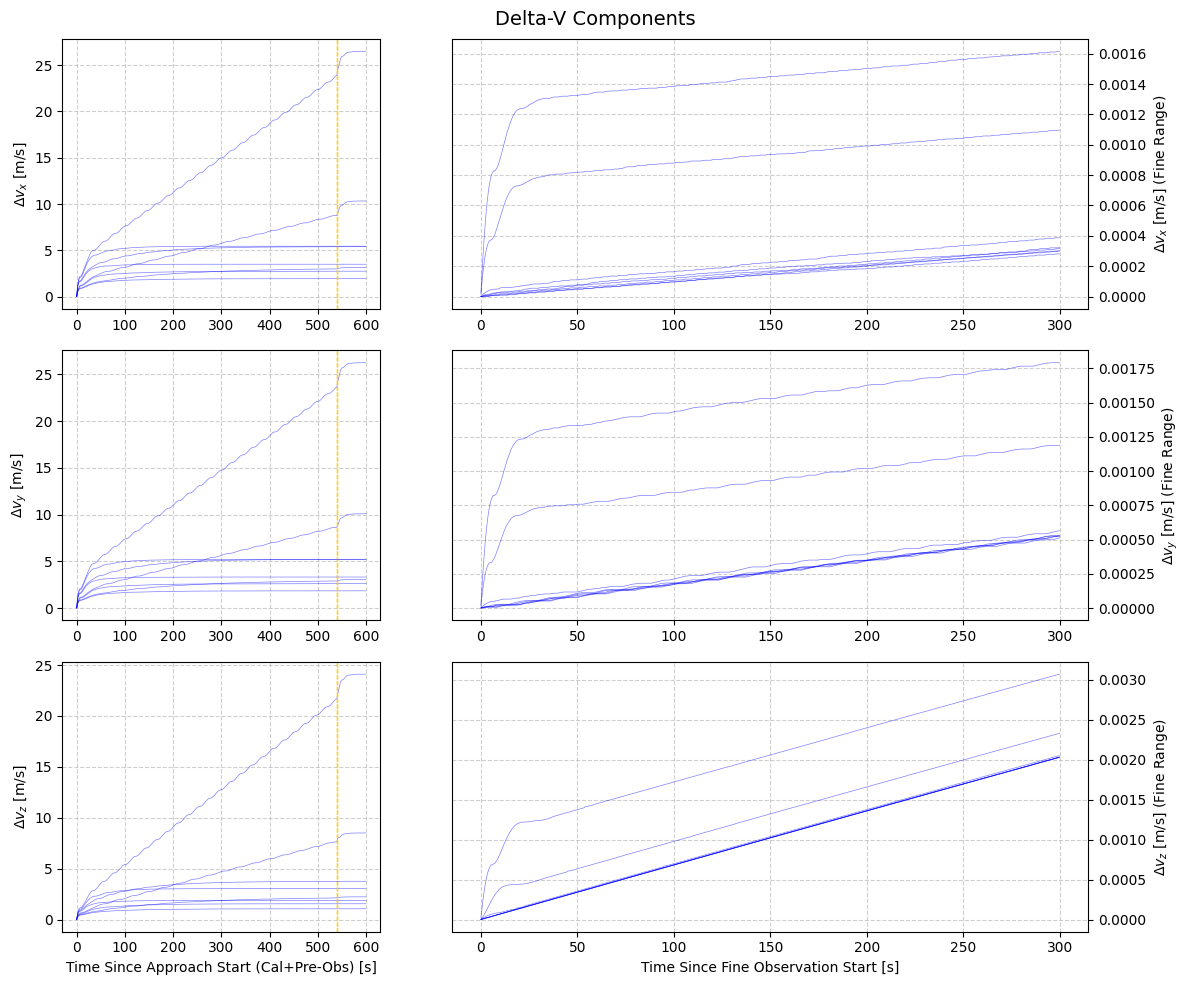

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

coord_letter = ["x", "y", "z"]
alpha_lines  = 0.5

dv_fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=dv_fig)
dv_fig.suptitle("Delta-V Components", fontsize=14)

dv_ax = []
for row in range(3):
    ax_approach = dv_fig.add_subplot(gs[row, 0])
    ax_fine     = dv_fig.add_subplot(gs[row, 1])
    ax_fine.yaxis.tick_right()
    ax_fine.yaxis.set_label_position("right")
    dv_ax.append((ax_approach, ax_fine))

dv_ax[2][0].set_xlabel("Time Since Approach Start (Cal+Pre-Obs) [s]")
dv_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")

for coord in range(len(coord_letter)):
    label = coord_letter[coord]
    dv_ax[coord][0].set_ylabel(f"$\\Delta v_{label}$ [m/s]")
    dv_ax[coord][1].set_ylabel(f"$\\Delta v_{label}$ [m/s] (Fine Range)")
    dv_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
    dv_ax[coord][1].grid(True, linestyle="--", alpha=0.6)

for i in range(len(phase)):
    t_full  = full_times[i]       # full-rate time — same length as phase array
    dv_run  = dv_xyz[i]           # also full-rate
    phase_i = np.array(phase[i], dtype=str)

    cal_idx     = np.where(phase_i == "Calibration")[0]
    pre_obs_idx = np.where(phase_i == "Pre-Observation")[0]
    fine_idx    = np.where(phase_i == "Fine Observation")[0]

    # Use full-rate indices directly (dv_xyz is also full-rate)
    approach_indices = np.concatenate([cal_idx, pre_obs_idx])
    if len(approach_indices) > 0:
        approach_mask = (t_full >= t_full[approach_indices[0]]) & (t_full <= t_full[approach_indices[-1]])
    else:
        approach_mask = np.zeros_like(t_full, dtype=bool)

    if len(fine_idx) > 0:
        fine_mask = (t_full >= t_full[fine_idx[0]]) & (t_full <= t_full[fine_idx[-1]])
    else:
        fine_mask = np.zeros_like(t_full, dtype=bool)

    app_t  = t_full[approach_mask];  app_dv  = dv_run[approach_mask]
    fine_t = t_full[fine_mask];      fine_dv = dv_run[fine_mask]

    if len(app_t) > 0:
        app_t = app_t - app_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    # Mark Pre-Obs boundary
    if len(pre_obs_idx) > 0 and len(approach_indices) > 0:
        pre_obs_t_start = t_full[pre_obs_idx[0]] - t_full[approach_indices[0]]
        for coord in range(3):
            dv_ax[coord][0].axvline(pre_obs_t_start, color="gold",
                                     lw=0.8, ls="--", alpha=0.7,
                                     label="Pre-Obs start" if i == 0 else None)

    for coord in range(3):
        if len(app_t) > 0:
            dv_ax[coord][0].plot(app_t,  app_dv[:,  coord], lw=0.5, color="blue", alpha=alpha_lines)
        if len(fine_t) > 0:
            dv_ax[coord][1].plot(fine_t, fine_dv[:, coord]-app_dv[-1, coord], lw=0.5, color="blue", alpha=alpha_lines)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)


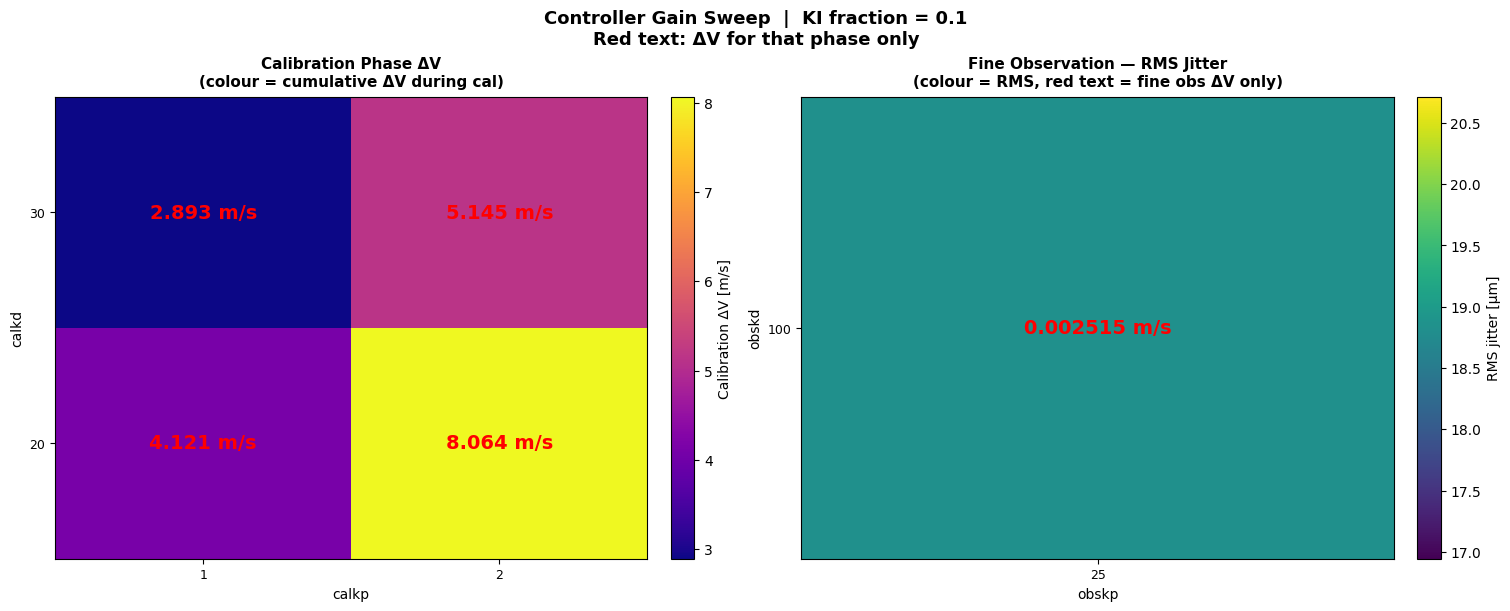

[KI=0.1]  Cal ΔV range: 2.893 – 8.064 m/s  |  Fine obs ΔV range: 2.5146 – 0.002515 m/s


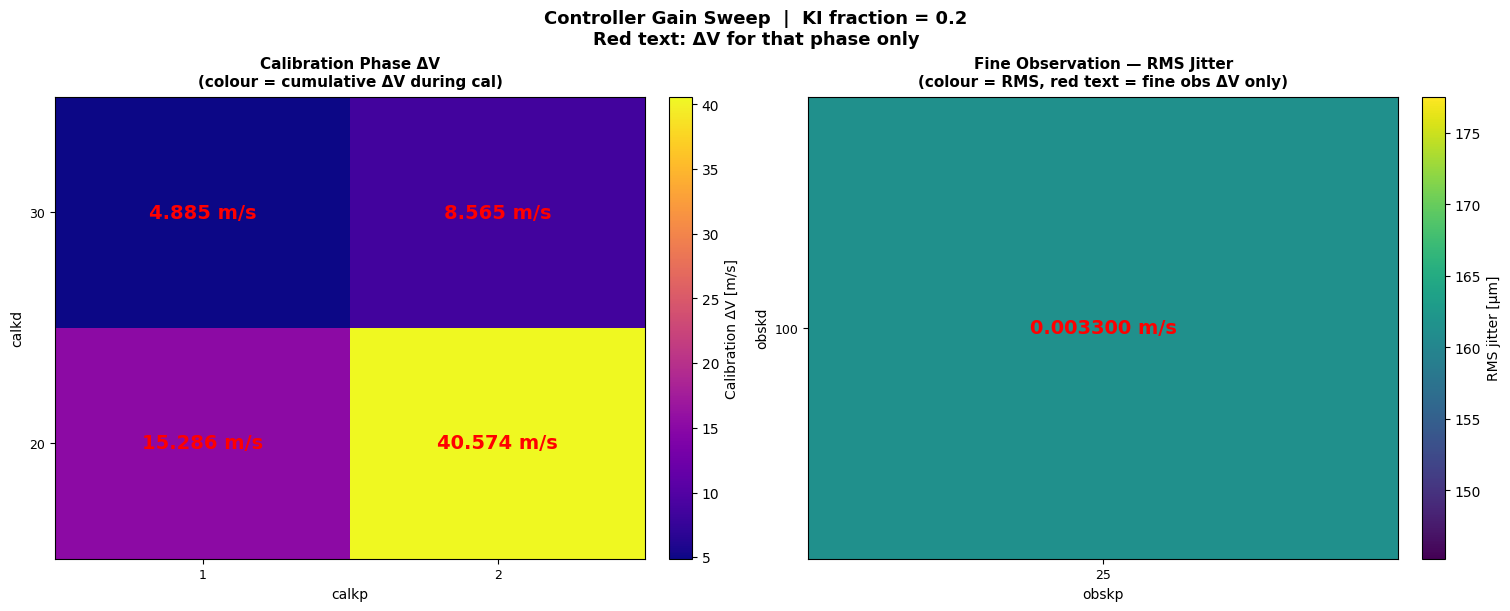

[KI=0.2]  Cal ΔV range: 4.885 – 40.574 m/s  |  Fine obs ΔV range: 3.3000 – 0.003300 m/s


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════
# Helper functions
# ═══════════════════════════════════════════════════════════════════

def phase_only_dv(i, phase_name):
    """ΔV consumed WITHIN `phase_name` only: dv[last] - dv[first] of that phase."""
    phase_i = np.array(phase[i], dtype=str)
    idx = np.where(phase_i == phase_name)[0]
    if len(idx) == 0:
        return np.nan
    return float(dv[i][idx[-1]] - dv[i][idx[0]])

def phase_rms_um(i, phase_name):
    """Lateral (x,y) RMS of rel_pos_B during `phase_name`, returned in µm."""
    phase_i = np.array(phase[i], dtype=str)
    idx     = np.where(phase_i == phase_name)[0]
    if len(idx) == 0:
        return np.nan
    t_start = full_times[i][idx[0]]
    t_end   = full_times[i][idx[-1]]
    mask    = (eng_times[i] >= t_start) & (eng_times[i] <= t_end)
    rel     = rel_pos_B[i][mask, :2]
    if rel.shape[0] == 0:
        return np.nan
    return float(np.sqrt(np.mean(rel**2)) * 1e6)

def mean_map(acc, n_rows, n_cols):
    """Reduce accumulator lists to a mean map and a text map."""
    data = np.full((n_rows, n_cols), np.nan)
    for r in range(n_rows):
        for c in range(n_cols):
            if acc[r][c]:
                data[r, c] = float(np.mean(acc[r][c]))
    return data

def plot_heatmap(ax, data, text_data, title, x_vals, y_vals,
                 cbar_label, xlabel, ylabel, cmap="viridis"):
    vmin, vmax = np.nanmin(data), np.nanmax(data)
    im = ax.imshow(data, aspect="auto", origin="lower",
                   cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels([f"{v:g}" for v in x_vals], fontsize=9)
    ax.set_yticks(range(len(y_vals)))
    ax.set_yticklabels([f"{v:g}" for v in y_vals], fontsize=9)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, text_data[r, c],
                    ha="center", va="center", fontsize=14,
                    color="red", fontweight="bold")

# ═══════════════════════════════════════════════════════════════════
# Unique axis values
# ═══════════════════════════════════════════════════════════════════
ki_unique    = sorted(set(round(v, 8) for v in ki_vals))
calkp_unique = sorted(set(round(v, 8) for v in calkp_vals))
calkd_unique = sorted(set(round(v, 8) for v in calkd_vals))
obskp_unique = sorted(set(round(v, 8) for v in obskp_vals))
obskd_unique = sorted(set(round(v, 8) for v in obskd_vals))

calkp_to_col = {v: j for j, v in enumerate(calkp_unique)}
calkd_to_row = {v: j for j, v in enumerate(calkd_unique)}
obskp_to_col = {v: j for j, v in enumerate(obskp_unique)}
obskd_to_row = {v: j for j, v in enumerate(obskd_unique)}

n_ckp = len(calkp_unique);  n_ckd = len(calkd_unique)
n_okp = len(obskp_unique);  n_okd = len(obskd_unique)

# ═══════════════════════════════════════════════════════════════════
# One figure per KI value
# ═══════════════════════════════════════════════════════════════════
for ki_target in ki_unique:
    run_ids = [i for i, ki in enumerate(ki_vals) if np.isclose(ki, ki_target)]

    # Accumulators (lists per cell to average over the "other" gain pair)
    cal_dv_acc   = [[[] for _ in range(n_ckp)] for _ in range(n_ckd)]   # [row=ckd][col=ckp]
    obs_rms_acc  = [[[] for _ in range(n_okp)] for _ in range(n_okd)]   # [row=okd][col=okp]
    obs_dv_acc   = [[[] for _ in range(n_okp)] for _ in range(n_okd)]

    for i in run_ids:
        ckp = round(calkp_vals[i], 8)
        ckd = round(calkd_vals[i], 8)
        okp = round(obskp_vals[i], 8)
        okd = round(obskd_vals[i], 8)

        cal_dv   = phase_only_dv(i, "Calibration")          # ΔV during calibration only
        fine_dv  = phase_only_dv(i, "Fine Observation")     # ΔV during fine obs only
        fine_rms = phase_rms_um(i, "Fine Observation")      # RMS jitter during fine obs [µm]

        if ckp in calkp_to_col and ckd in calkd_to_row:
            r, c = calkd_to_row[ckd], calkp_to_col[ckp]
            if np.isfinite(cal_dv):
                cal_dv_acc[r][c].append(cal_dv)

        if okp in obskp_to_col and okd in obskd_to_row:
            r, c = obskd_to_row[okd], obskp_to_col[okp]
            if np.isfinite(fine_rms):
                obs_rms_acc[r][c].append(fine_rms)
            if np.isfinite(fine_dv):
                obs_dv_acc[r][c].append(fine_dv)

    # ── Reduce to maps ──────────────────────────────────────────────
    cal_dv_map  = mean_map(cal_dv_acc,  n_ckd, n_ckp)
    obs_rms_map = mean_map(obs_rms_acc, n_okd, n_okp)
    obs_dv_map  = mean_map(obs_dv_acc,  n_okd, n_okp)

    # ── Build text annotations ──────────────────────────────────────
    cal_text = np.full((n_ckd, n_ckp), "", dtype=object)
    for r in range(n_ckd):
        for c in range(n_ckp):
            v = cal_dv_map[r, c]
            cal_text[r, c] = f"{v:.3f} m/s" if np.isfinite(v) else "NA"

    obs_text = np.full((n_okd, n_okp), "", dtype=object)
    for r in range(n_okd):
        for c in range(n_okp):
            v = obs_dv_map[r, c]
            # Fine obs ΔV is tiny — display in mm/s for readability
            obs_text[r, c] = f"{v:.6f} m/s" if np.isfinite(v) else "NA"

    # ── Plot ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
    fig.suptitle(
        f"Controller Gain Sweep  |  KI fraction = {ki_target:g}\n"
        f"Red text: ΔV for that phase only",
        fontsize=13, fontweight="bold"
    )

    plot_heatmap(
        axes[0],
        cal_dv_map, cal_text,
        "Calibration Phase ΔV\n(colour = cumulative ΔV during cal)",
        calkp_unique, calkd_unique,
        "Calibration ΔV [m/s]", "calkp", "calkd",
        cmap="plasma",
    )

    plot_heatmap(
        axes[1],
        obs_rms_map, obs_text,
        "Fine Observation — RMS Jitter\n(colour = RMS, red text = fine obs ΔV only)",
        obskp_unique, obskd_unique,
        "RMS jitter [µm]", "obskp", "obskd",
        cmap="viridis",
    )

    fig.savefig(f"controller_sweep_ki{ki_target:g}.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[KI={ki_target:g}]  Cal ΔV range: "
          f"{np.nanmin(cal_dv_map):.3f} – {np.nanmax(cal_dv_map):.3f} m/s  |  "
          f"Fine obs ΔV range: "
          f"{np.nanmin(obs_dv_map)*1e3:.4f} – {np.nanmax(obs_dv_map):.6f} m/s")
